<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_068_elbow_silhouette.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 68/365 — Elbow Method & Silhouette Score
## How do we choose the right number of clusters in K-Means?

Yesterday we explored **K-Means Clustering**.

But K-Means needs us to choose:

`K = number of clusters`

Two popular techniques for choosing K are:

- **Elbow Method**
- **Silhouette Score**


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 1. Create sample clustered data


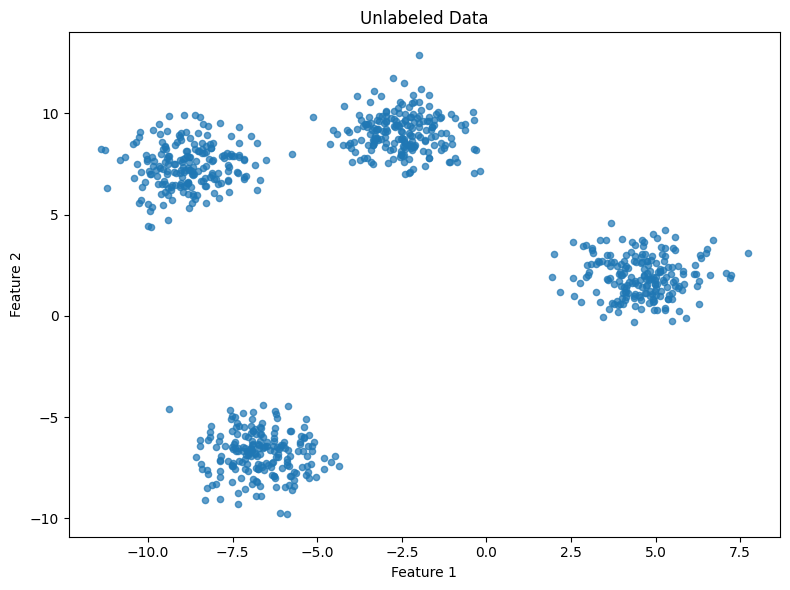

In [ ]:
X,_=make_blobs(
    n_samples=800,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],s=20,alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled Data")
plt.tight_layout()
plt.show()


## 2. Elbow Method

K-Means tries to minimize **inertia**:

the sum of squared distances between each point and its assigned centroid.

Increasing K almost always lowers inertia.

So we look for the point where improvement starts slowing down:

**the elbow**


In [ ]:
k_values=range(1,11)
inertias=[]

for k in k_values:
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertias.append(model.inertia_)

elbow_df=pd.DataFrame({
    "K":list(k_values),
    "Inertia":inertias
})

display(elbow_df.round(2))


,K,Inertia
0,1,53176.15
1,2,25115.59
2,3,5827.84
3,4,1569.83
4,5,1414.92
5,6,1270.28
6,7,1131.04
7,8,1005.93
8,9,922.32
9,10,828.33


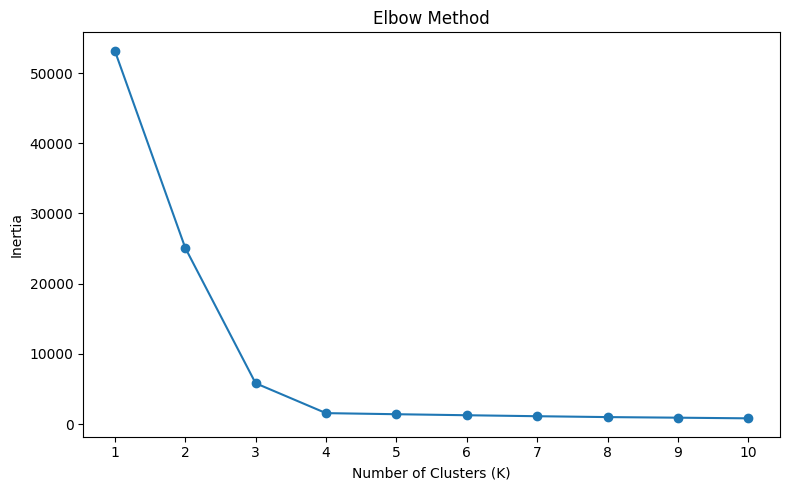

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    elbow_df["K"],
    elbow_df["Inertia"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


## 3. Silhouette Score

Silhouette Score considers both:

- cohesion: how close a point is to its own cluster
- separation: how far it is from the nearest other cluster

Rough interpretation:

- close to +1 → good separation
- around 0 → near a boundary
- negative → possibly assigned to the wrong cluster


In [ ]:
silhouette_results=[]

for k in range(2,11):
    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(X)

    score=silhouette_score(
        X,
        labels
    )

    silhouette_results.append({
        "K":k,
        "Silhouette Score":score
    })

silhouette_df=pd.DataFrame(silhouette_results)

display(silhouette_df.round(3))


,K,Silhouette Score
0,2,0.589
1,3,0.752
2,4,0.789
3,5,0.685
4,6,0.556
5,7,0.432
6,8,0.335
7,9,0.345
8,10,0.343


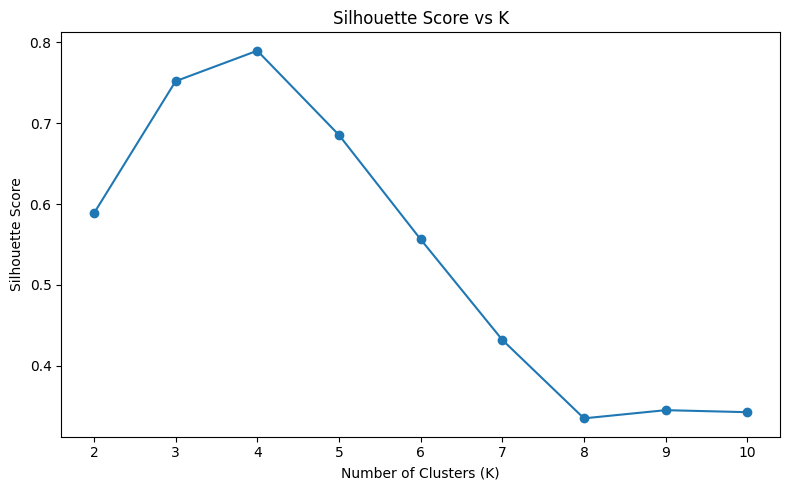

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(silhouette_df["K"])
plt.tight_layout()
plt.show()


## 4. Choose K

A practical approach is to combine:

- Elbow Method
- Silhouette Score
- domain knowledge

For this synthetic dataset, both should point toward approximately:

`K = 4`


In [ ]:
best_k=int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

print("Best K by Silhouette Score:",best_k)


Best K by Silhouette Score: 4


## 5. Train final K-Means model


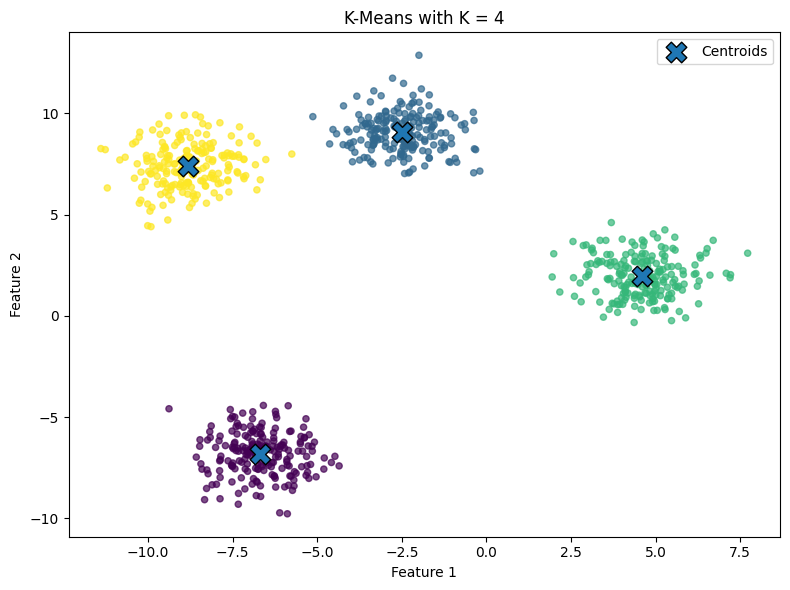

In [ ]:
final_model=KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_labels=final_model.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=final_labels,
    s=20,
    alpha=0.7
)

plt.scatter(
    final_model.cluster_centers_[:,0],
    final_model.cluster_centers_[:,1],
    s=220,
    marker="X",
    edgecolors="black",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"K-Means with K = {best_k}")
plt.legend()
plt.tight_layout()
plt.show()


## Enterprise intuition

Suppose we are segmenting customers.

Mathematically, more clusters may keep reducing inertia.

But 12 customer segments might be too complicated for a marketing team to actually use.

So the best K should also be:

- understandable
- actionable
- stable
- useful for the business


## Important limitations

- The elbow may not always be obvious.
- Silhouette Score may prefer a mathematically clean result that is not operationally useful.
- Both can struggle when clusters have irregular shapes or very different densities.
- Sometimes K-Means itself is simply the wrong clustering algorithm.

These methods are decision aids, not universal rules.


## What does this teach?

- K-Means requires us to choose K.
- Inertia measures within-cluster squared distance.
- The Elbow Method looks for diminishing returns.
- Silhouette Score measures cohesion and separation.
- Higher Silhouette Score is generally better.
- Final K should combine metrics with domain knowledge.

> **Choosing K is not about blindly minimizing inertia. It is about finding a useful balance between compact clusters and meaningful separation.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html
- https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation
